# XWorld — Dataset 3: Lynx-Hare Population

**Goal**: Load the classic Hudson's Bay Company lynx-hare dataset (1900–1920), extract both predator and prey series, z-score normalize, extract 7 shape features.

**Dynamic type**: Coupled predator-prey oscillation — phase-shifted cycles

In [1]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


## 1. Load the dataset

Classic Hudson's Bay Company pelt data 1900–1920. Both lynx (predator) and hare (prey) series.

In [2]:
# Hudson's Bay Company lynx-hare data — embedded directly (public domain historical data)
# Source: Odum (1953), widely reproduced in ecology textbooks
data = {
    'year': list(range(1900, 1921)),
    'hare': [30.0, 47.2, 70.2, 77.4, 36.3, 20.6, 18.1, 21.4, 22.0, 25.4,
             27.1, 40.3, 57.0, 76.6, 52.3, 19.5, 11.2, 7.6,  14.6, 16.2, 24.7],
    'lynx': [4.0,  6.1,  9.8,  35.2, 59.4, 41.7, 19.0, 13.0, 8.3,  9.1,
             7.4,  8.0,  12.3, 19.5, 45.7, 51.1, 29.7, 15.8, 9.7,  10.1, 8.6]
}

df = pd.DataFrame(data)
df.to_csv(RAW_DIR / 'lynx_hare.csv', index=False)
print(f'Rows: {len(df)}')
print(f'Years: {df.year.min()} to {df.year.max()}')
df.head()

Rows: 21
Years: 1900 to 1920


,year,hare,lynx
0,1900,30.0,4.0
1,1901,47.2,6.1
2,1902,70.2,9.8
3,1903,77.4,35.2
4,1904,36.3,59.4


## 2. Plot the raw series

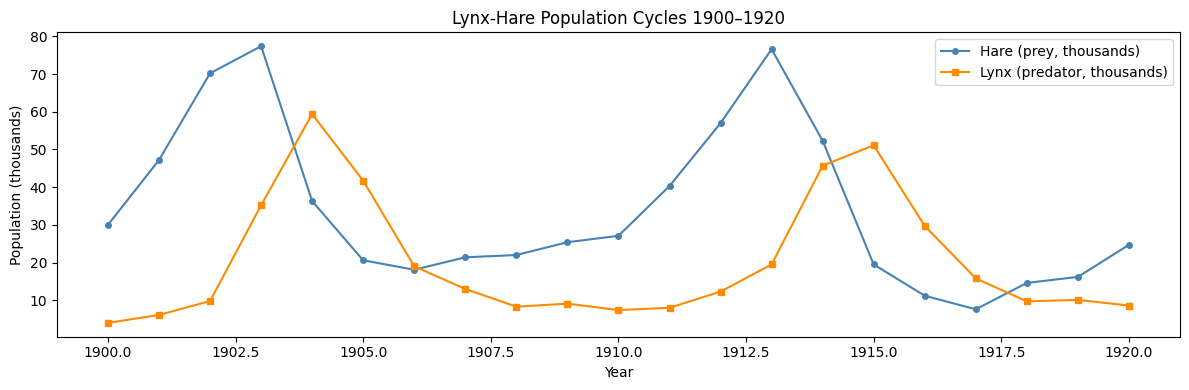

Hare peaks at: 1903, Lynx peaks at: 1904
Phase lag: 1 years


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['year'], df['hare'], color='steelblue', marker='o', markersize=4, label='Hare (prey, thousands)')
ax.plot(df['year'], df['lynx'], color='darkorange', marker='s', markersize=4, label='Lynx (predator, thousands)')
ax.set_title('Lynx-Hare Population Cycles 1900–1920', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Population (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'lynx_hare_raw.png', dpi=120, bbox_inches='tight')
plt.show()

# Note the phase lag: hare peaks first, lynx follows ~2 years later
hare_peak = df.loc[df['hare'].idxmax(), 'year']
lynx_peak = df.loc[df['lynx'].idxmax(), 'year']
print(f'Hare peaks at: {hare_peak}, Lynx peaks at: {lynx_peak}')
print(f'Phase lag: {lynx_peak - hare_peak} years')

## 3. Treat each species as a separate time series instance

Also create windowed sub-series (rolling windows of 10 years) to increase instances.
This gives us more than 2 data points from one dataset.

In [4]:
window_size = 10  # years
series_dict = {}

for species in ['hare', 'lynx']:
    full = df[species].values
    # Full series
    series_dict[f'{species}_full'] = full
    # Sliding windows
    for start in range(len(full) - window_size + 1):
        window = full[start:start + window_size]
        year_start = df['year'].iloc[start]
        series_dict[f'{species}_w{start}_{year_start}'] = window

print(f'Total series (full + windowed): {len(series_dict)}')

Total series (full + windowed): 26


## 4. Z-score normalize and overlay

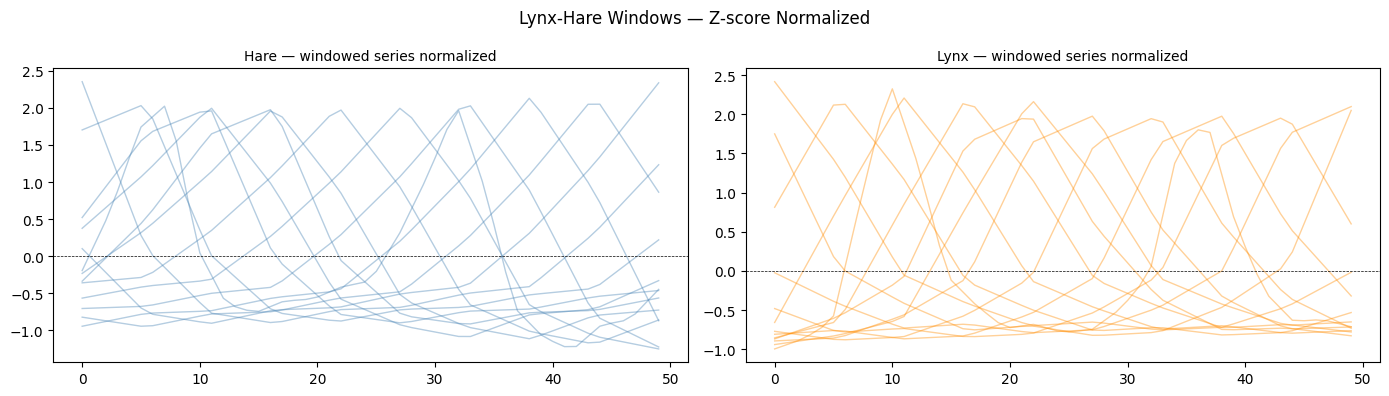

In [5]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

series_norm = {name: zscore_normalize(s) for name, s in series_dict.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, species, color in zip(axes, ['hare', 'lynx'], ['steelblue', 'darkorange']):
    subset = {k: v for k, v in series_norm.items() if k.startswith(species)}
    for name, s in subset.items():
        x = np.linspace(0, 1, len(s))
        x_new = np.linspace(0, 1, 50)
        ax.plot(np.interp(x_new, x, s), alpha=0.4, linewidth=1.0, color=color)
    ax.set_title(f'{species.title()} — windowed series normalized', fontsize=10)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.suptitle('Lynx-Hare Windows — Z-score Normalized', fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'lynx_hare_normalized.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Extract features

In [6]:
def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zero_crossings = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean':           series.mean(),
        'std':            series.std(),
        'skewness':       stats.skew(series),
        'kurtosis':       stats.kurtosis(series),
        'lag1_autocorr':  lag1,
        'zero_crossings': zero_crossings,
        'slope':          slope,
    }

records = []
for name, s in series_norm.items():
    feats = extract_features(s)
    feats['country'] = name
    feats['dataset'] = 'lynx_hare'
    feats['n_points'] = len(s)
    records.append(feats)

df_features = pd.DataFrame(records)
print(f'Feature matrix shape: {df_features.shape}')
df_features.head()

Feature matrix shape: (26, 10)


,mean,std,skewness,kurtosis,lag1_autocorr,zero_crossings,slope,country,dataset,n_points
0,-7.480788e-16,1.0,0.870793,-0.471385,0.695483,0.190476,-0.064270,hare_full,lynx_hare,21
1,5.551115e-17,1.0,1.018627,-0.482238,0.646723,0.200000,-0.195768,hare_w0_1900,lynx_hare,10
2,-2.942091e-16,1.0,1.036794,-0.477498,0.691038,0.100000,-0.243151,hare_w1_1901,lynx_hare,10
3,-4.801715e-16,1.0,1.165544,-0.201839,0.704325,0.200000,-0.200975,hare_w2_1902,lynx_hare,10
4,-1.332268e-16,1.0,1.286177,0.465400,0.440720,0.200000,-0.033506,hare_w3_1903,lynx_hare,10


## 6. Save

In [7]:
out_path = PROCESSED_DIR / 'features_lynx_hare.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

feature_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print('\nShape feature summary:')
print(df_features[feature_cols].describe().round(3))

Saved: ../data/processed/features_lynx_hare.csv

Shape feature summary:
       skewness  kurtosis  lag1_autocorr  zero_crossings   slope
count    26.000    26.000         26.000          26.000  26.000
mean      1.025    -0.302          0.680           0.172  -0.022
std       0.204     0.394          0.111           0.045   0.182
min       0.660    -0.807          0.373           0.100  -0.274
25%       0.936    -0.529          0.634           0.123  -0.199
50%       1.023    -0.451          0.679           0.200  -0.047
75%       1.127    -0.135          0.729           0.200   0.109
max       1.491     0.834          0.894           0.200   0.300


---
## Status
- Lynx-hare series extracted and features saved
- Next: `04_keeling_pipeline.ipynb` — CO2 seasonal cycle + long-term drift